In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/GOOG.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,GOOG,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,GOOG,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,GOOG,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,GOOG,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,GOOG,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,GOOG,7.633949,7.960977,7.557264,7.948608,144961322
2009-01-05,GOOG,7.940692,8.194003,7.792268,8.115089,196293007
2009-01-06,GOOG,8.237046,8.430492,8.074027,8.263762,257971329
2009-01-07,GOOG,8.121770,8.185839,7.885034,7.965677,180453860
2009-01-08,GOOG,7.873406,8.044340,7.850152,8.044340,144567852


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,50.753534,51.285163,50.252347,50.779971,6.123096e+07
std,39.389736,39.853299,38.975050,39.417443,5.537396e+07
min,7.133018,7.408840,6.994490,6.994490,1.584340e+05
25%,16.827651,16.984424,16.699388,16.851089,2.574863e+07
50%,37.388390,37.647668,37.038786,37.327805,3.797798e+07
75%,69.062883,70.084894,68.368832,69.191502,8.269781e+07
max,150.831319,151.066223,148.868758,149.684662,5.952147e+08


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,GOOG,141.164014,142.276397,141.089511,141.750000,18513500,135.009596,133.914786,135.009596,133.914786,64.953309,1.412015,0.572046,0.839969
2023-12-26,GOOG,142.008205,142.966658,141.531472,141.849304,11170100,135.246477,133.999010,135.246477,133.999010,65.115870,1.706565,0.798950,0.907615
2023-12-27,GOOG,141.859236,142.345911,140.092320,140.478683,17288400,135.386520,134.017881,135.386520,134.017881,60.916026,1.808553,1.000870,0.807682
2023-12-28,GOOG,140.885881,141.303025,139.870824,140.319748,12192500,135.628861,134.023641,135.628861,134.023641,60.429303,1.855168,1.171730,0.683438
2023-12-29,GOOG,139.723837,140.473710,138.949139,139.972137,14881000,135.976979,134.056417,135.976979,134.056417,59.313063,1.842820,1.305948,0.536872


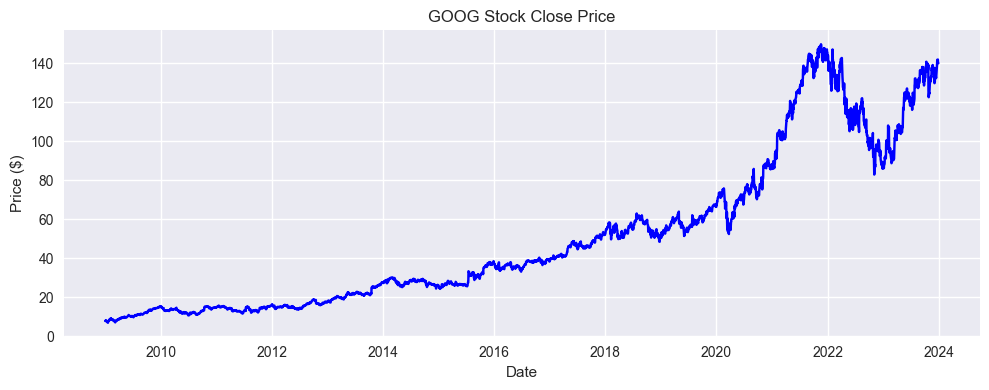

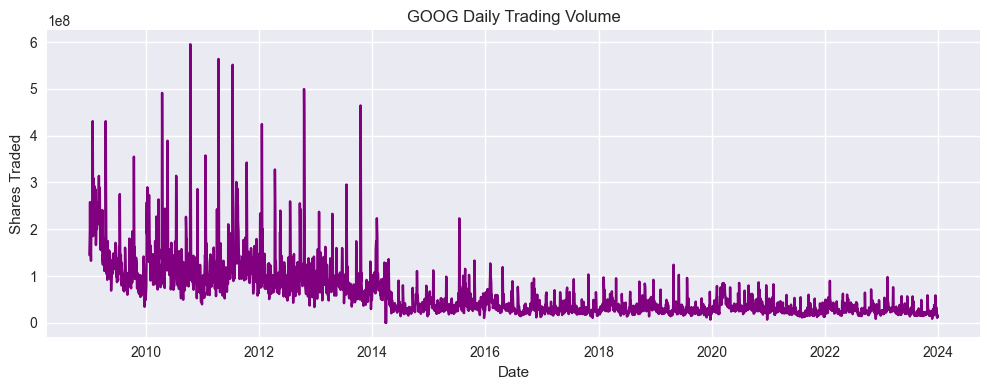

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)